### Business Context:
Vehicle breakdowns and engine failures lead to significant financial losses for both individual owners and fleet operators. Unexpected engine failures can cause expensive repairs, operational downtime, and safety risks. Predictive maintenance in the automotive industry can help minimize these issues by leveraging sensor data to forecast potential failures before they occur. 

Automobile manufacturers, fleet managers, and service providers aim to develop data-driven solutions to improve engine reliability and optimize maintenance schedules. By analyzing engine health parameters such as RPM, temperature, pressure, and other sensor readings, machine learning models can be trained to predict when an engine requires maintenance, allowing proactive intervention before a failure occurs. 

The sensor values in the dataset are consistent with the operating parameters of larger and small engines commonly found in equipment like Vechiles, lawnmowers, portable generators, and compact machinery. Some engines operate at lower RPMs, pressures, and temperatures compared to larger automotive engines and vice versa. Therefore, the data is appropriate for developing predictive maintenance models tailored to large and small engine applications. 

### Objective:
As a Data Scientist, your goal is to build a predictive maintenance model that can analyze historical and real-time engine sensor data to identify potential failures. The model should accurately classify whether an engine requires maintenance or is operating normally. 

This solution will help:

Reduce unplanned breakdowns and costly repairs.
Improve vehicle performance and engine lifespan.
Optimize maintenance schedules to minimize downtime
Provide data-driven insights to manufacturers and fleet operators for better decision-making. 

### Approach:
To achieve this objective, you will: 

Explore and preprocess the dataset, handling missing values, outliers, and sensor anomalies.
Perform exploratory data analysis (EDA) to identify patterns in engine health parameters.
Develop machine learning models (e.g., Decision Trees, Random Forest, XGBoost, or Deep Learning models) to predict engine failures.
Evaluate model performance using appropriate classification metrics such as accuracy, precision, recall, and F1-score.
Deploy the model in a real-time monitoring system to alert users about potential failures. 
By implementing a robust predictive maintenance system, this solution can lead to significant cost savings and improved efficiency in the automotive sector.

### Data Description:
- Engine_RPM: The number of revolutions per minute (RPM) of the engine, indicating engine speed. It is defined in Revolutions per Minute (RPM). 
- Lub_Oil_Pressure: The pressure of the lubricating oil in the engine, essential for reducing friction and wear. It is defined in bar or kilopascals (kPa) 
- Fuel_Pressure: The pressure at which fuel is supplied to the engine, critical for proper combustion. It is defined in bar or kilopascals (kPa) 
- Coolant_Pressure: The pressure of the engine coolant, affecting engine temperature regulation. It is defined in bar or kilopascals (kPa) 
- Lub_Oil_Temperature: The temperature of the lubricating oil, which impacts viscosity and engine performance. It is defined in degrees Celsius (°C) 
- Coolant_Temperature: The temperature of the engine coolant, crucial for preventing overheating. It is defined in degrees Celsius (°C) 
- Engine_Condition: A categorical or numerical label representing the health of the engine, potentially indicating normal operation or various levels of wear and failure risks. It is defined as a categorical variable (0/1) representing a state such as "0 = Off/False/Active" and "1 = On/True/Faulty"




### Evaluation Rubrics for Report

| Section | Description | Points |
|---|---|---|
| Data Registration | - Create a master folder and create a subfolder "data"<br>- Register the data on the Hugging Face dataset space | 6 |
| Exploratory Data Analysis | - Data collection and background<br>- Data overview<br>- Univariate analysis<br>- Bivariate analysis<br>- Multivariate analysis<br>- Insights/observations based on EDA | 10 |
| Data Preparation | - Load the dataset directly from the Hugging Face data space.<br>- Perform data cleaning and remove any unnecessary columns.<br>- Split the cleaned dataset into training and testing sets, and save them locally.<br>- Upload the resulting train and test datasets back to the Hugging Face data space. | 10 |
| Model Building with Experimentation Tracking | - Load the train and test data from the Hugging Face data space<br>- Define a model and parameters<br>- Tune the model with the defined parameters<br>- Log all the tuned parameters<br>- Evaluate the model performance<br>- Register the best model in the Hugging Face model hub<br>\* The ML models to be built can be any of the following algorithms, such as Decision Tree, Bagging, Random Forest, AdaBoost, Gradient Boosting, and XGBoost | 8 |
| Business Report Quality | - Adhere to the business report checklist | 6 |
| **Total** | | **40** |

---
## 2. Setup & Environment

### 2.1 Methodology
- Create the project's master folder structure with a `data/` subfolder (required by the rubric).
- Load the Hugging Face access token from a local `.env` file (kept outside version control).
- Authenticate against the Hugging Face Hub and resolve the dataset and model repository identifiers used throughout the notebook.
- Pin global plotting and warning options for consistent, presentation-ready output.


In [1]:
import os
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# Load HF_TOKEN from .env
load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")
print("HF_TOKEN:", "Set" if HF_TOKEN else "Not set")

# Master folder structure (as required by rubric)
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "predictive_maintenance" / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", PROJECT_ROOT)
print("Data folder :", DATA_DIR)

HF_TOKEN: Set
Project root: c:\POC\Python\Capstone Project AIML
Data folder : c:\POC\Python\Capstone Project AIML\predictive_maintenance\data


In [ ]:
from huggingface_hub import HfApi

api = HfApi(token=HF_TOKEN)
user_info = api.whoami()
HF_USER = user_info["name"]
print("Authenticated as:", HF_USER)

# Repo identifiers used throughout the notebook
DATASET_REPO_ID = f"{HF_USER}/engine-predictive-maintenance"
MODEL_REPO_ID   = f"{HF_USER}/engine-predictive-maintenance-model"
print("Dataset repo  :", DATASET_REPO_ID)
print("Model repo    :", MODEL_REPO_ID)

Authenticated as: debasishdas1985
Dataset repo  : debasishdas1985/engine-predictive-maintenance
Model repo    : debasishdas1985/engine-predictive-maintenance-model


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Methodology
- Load the raw CSV and inspect schema, dtypes, missing values and duplicates.
- **Univariate analysis:** histograms (with KDE) and boxplots to understand individual sensor distributions, skew and outliers.
- **Bivariate analysis:** class-wise boxplots and group means to compare each sensor across healthy vs faulty engines.
- **Multivariate analysis:** Pearson correlation heat-map and a coloured pair-plot (on a 2,000-row sample for speed) to surface joint structure.
- Document insights in plain business language to drive modelling decisions.

### 4.2 Data Collection & Background
The dataset contains sensor readings collected from engines (small to large displacement). Each row is a snapshot of an engine's operating state with six sensor features and a binary health label `Engine Condition` (0 = healthy/active, 1 = faulty / needs maintenance).

**Table 1 — Feature dictionary**

| Column | Unit | Meaning |
|---|---|---|
| Engine rpm | RPM | Engine rotational speed |
| Lub oil pressure | bar / kPa | Lubricating oil pressure |
| Fuel pressure | bar / kPa | Fuel-supply pressure |
| Coolant pressure | bar / kPa | Coolant pressure |
| lub oil temp | °C | Lubricating oil temperature |
| Coolant temp | °C | Coolant temperature |
| Engine Condition | 0/1 | Target — 1 = faulty |


### 4.3 Data Overview

*Table 2 — First five rows of the raw dataset.*


In [5]:
df = pd.read_csv(DATA_DIR / "engine_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (19535, 7)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [6]:
print("--- info ---")
df.info()
print("\n--- missing values ---")
print(df.isna().sum())
print("\n--- duplicates ---", df.duplicated().sum())
print("\n--- target distribution ---")
print(df["Engine Condition"].value_counts(normalize=True).round(4))

--- info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB

--- missing values ---
Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
Engine Condition    0
dtype: int64

--- duplicates --- 0

--- target distribution ---
Engine Condition
1    0.6305
0    0.3695
Name: proportion, dtype: float64


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine rpm,19535.0,791.239263,267.611193,61.000000,593.000000,746.000000,934.000000,2239.000000
Lub oil pressure,19535.0,3.303775,1.021643,0.003384,2.518815,3.162035,4.055272,7.265566
Fuel pressure,19535.0,6.655615,2.761021,0.003187,4.916886,6.201720,7.744973,21.138326
Coolant pressure,19535.0,2.335369,1.036382,0.002483,1.600466,2.166883,2.848840,7.478505
lub oil temp,19535.0,77.643420,3.110984,71.321974,75.725990,76.817350,78.071691,89.580796
Coolant temp,19535.0,78.427433,6.206749,61.673325,73.895421,78.346662,82.915411,195.527912
Engine Condition,19535.0,0.630509,0.482679,0.000000,0.000000,1.000000,1.000000,1.000000


### 4.4 Univariate Analysis

Figures 1, 2 and 3 below summarise the distribution, spread and target balance for each sensor.


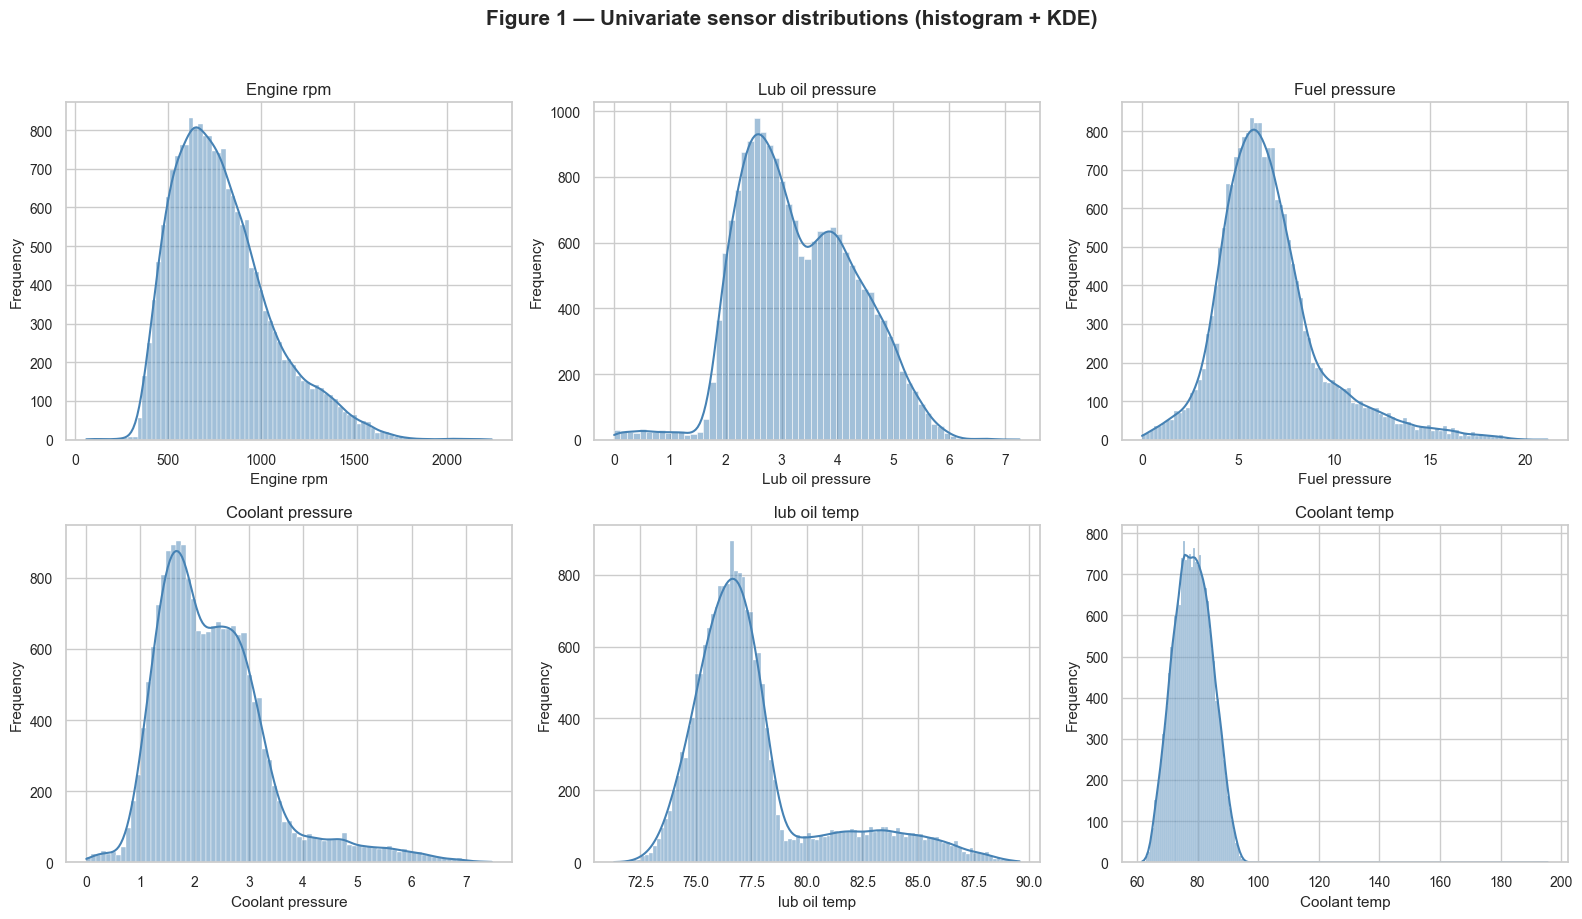

In [8]:
# Figure 1 — Sensor distributions (histograms with KDE)
numeric_features = [
    "Engine rpm", "Lub oil pressure", "Fuel pressure",
    "Coolant pressure", "lub oil temp", "Coolant temp",
]
target = "Engine Condition"

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Figure 1 — Univariate sensor distributions (histogram + KDE)",
             fontsize=15, fontweight="bold", y=1.02)
for ax, col in zip(axes.flat, numeric_features):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()


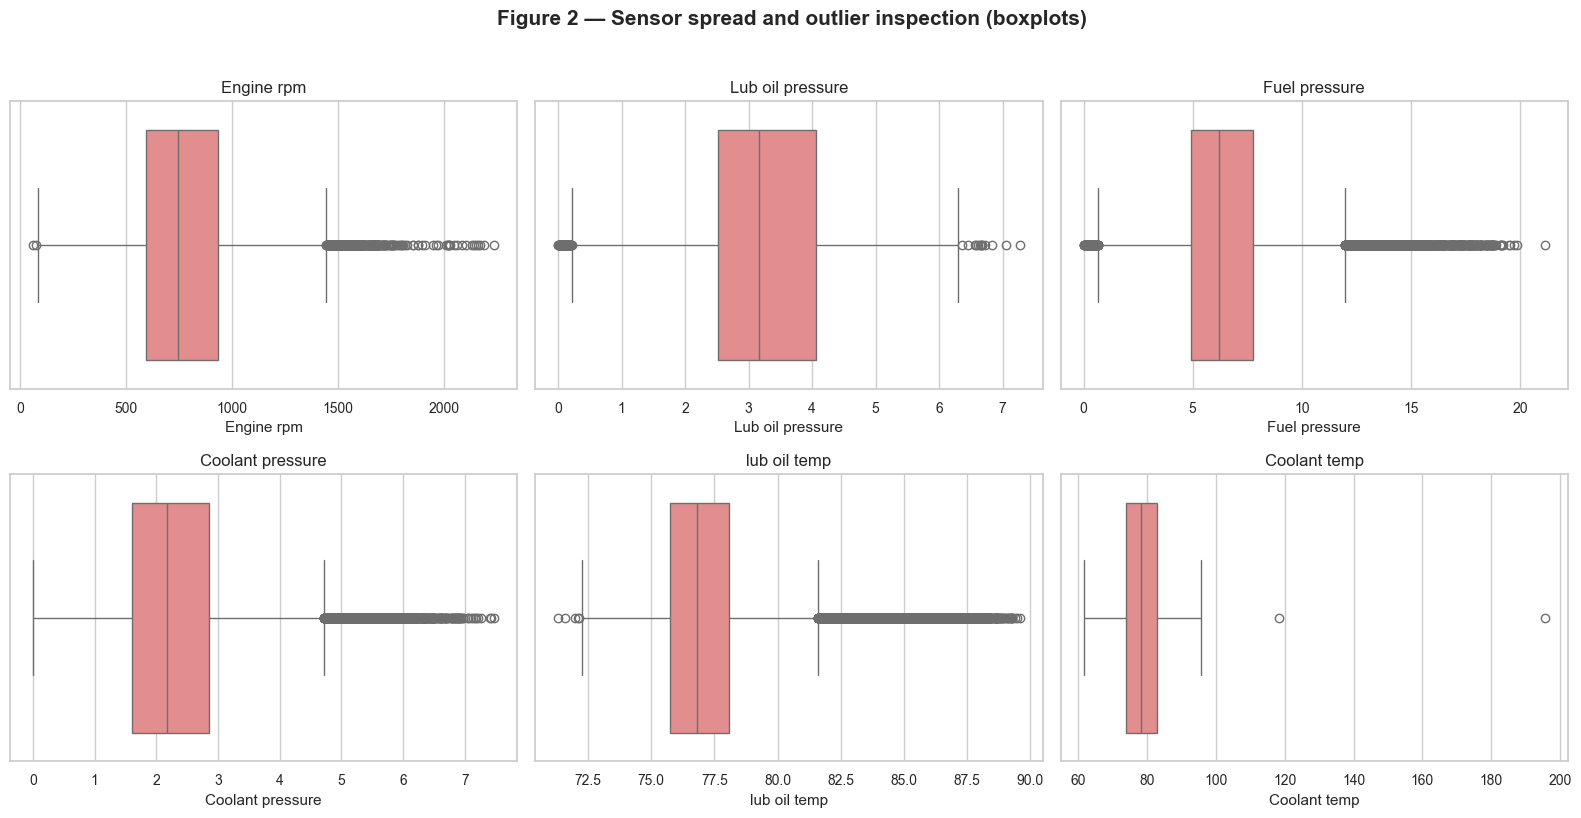

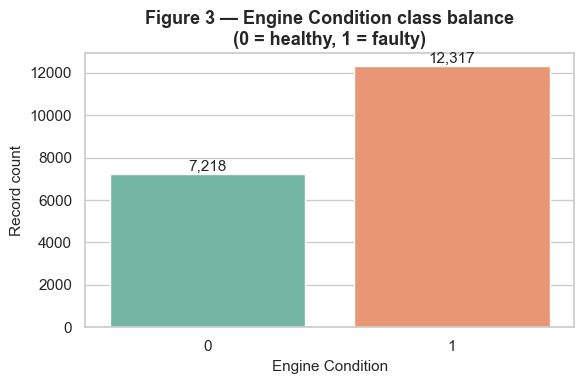

In [9]:
# Figure 2 — Boxplots: spread and outliers per sensor
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Figure 2 — Sensor spread and outlier inspection (boxplots)",
             fontsize=15, fontweight="bold", y=1.02)
for ax, col in zip(axes.flat, numeric_features):
    sns.boxplot(x=df[col], ax=ax, color="lightcoral")
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(col, fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()

# Figure 3 — Target class balance
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=target, data=df, palette="Set2")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.title("Figure 3 — Engine Condition class balance\n(0 = healthy, 1 = faulty)",
          fontsize=13, fontweight="bold")
plt.xlabel("Engine Condition", fontsize=11)
plt.ylabel("Record count", fontsize=11)
plt.tight_layout()
plt.show()


### 4.5 Bivariate Analysis — Each feature vs target

Figure 4 compares each sensor across the two engine-health classes; Table 3 lists the class-wise means.


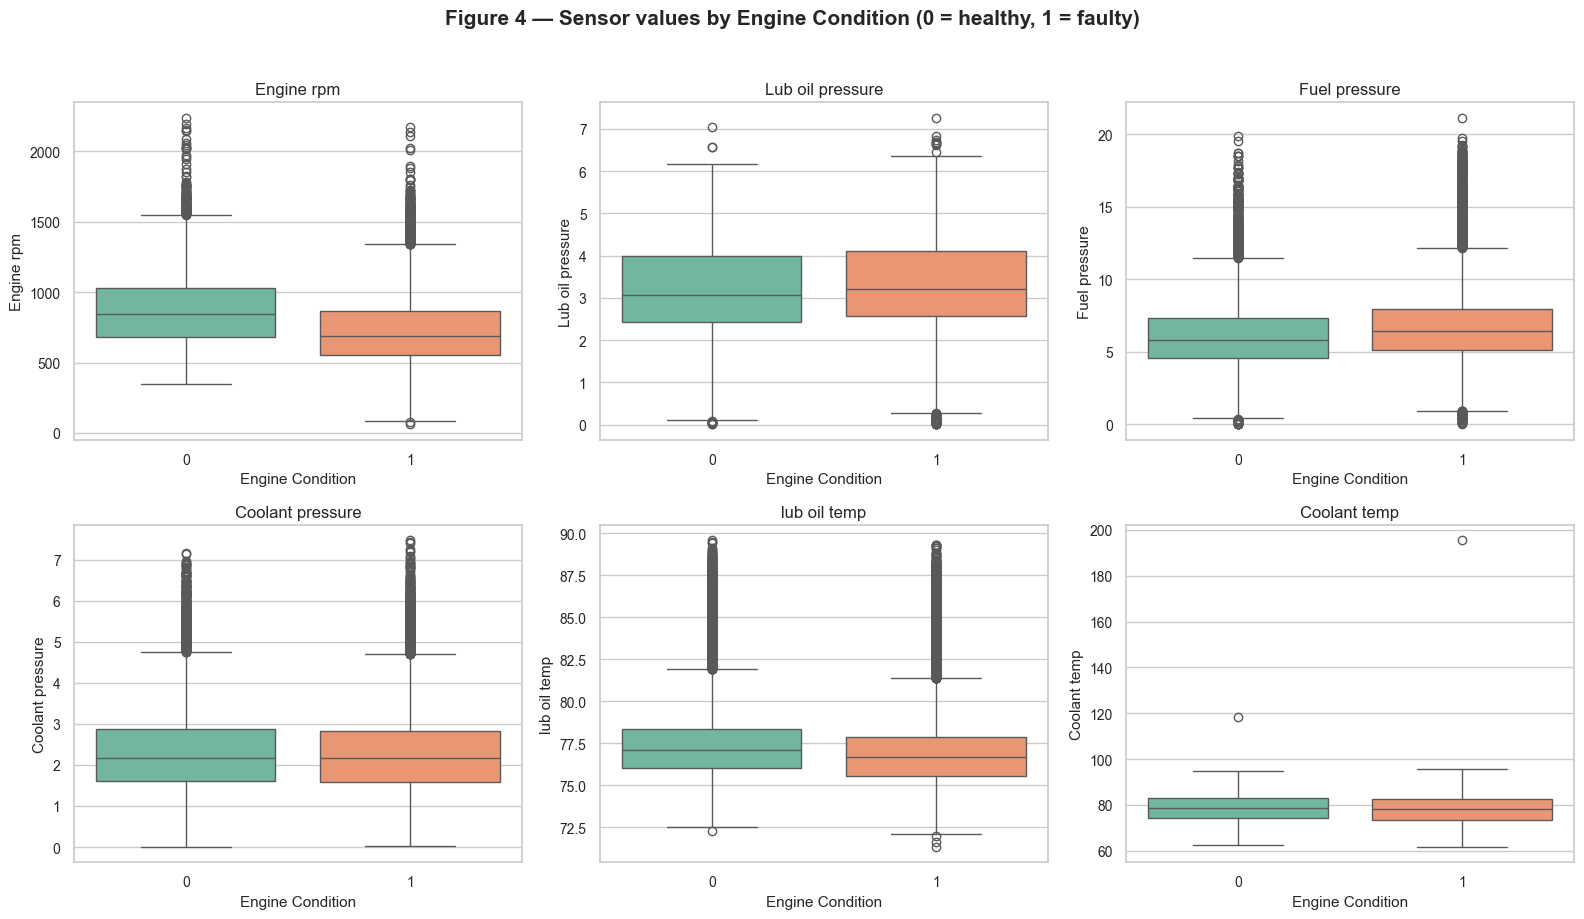

Table 3 — Mean sensor values per Engine Condition class


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
Engine Condition,,,,,,
0,884.995,3.222,6.236,2.368,78.024,78.803
1,736.297,3.351,6.901,2.316,77.420,78.207


In [10]:
# Figure 4 — Sensor distributions split by Engine Condition
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Figure 4 — Sensor values by Engine Condition (0 = healthy, 1 = faulty)",
             fontsize=15, fontweight="bold", y=1.02)
for ax, col in zip(axes.flat, numeric_features):
    sns.boxplot(x=target, y=col, data=df, ax=ax, palette="Set2")
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("Engine Condition", fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
plt.show()

# Table 3 — Class-wise group means
print("Table 3 — Mean sensor values per Engine Condition class")
df.groupby(target)[numeric_features].mean().round(3)


### 4.6 Multivariate Analysis — Correlation & pair relationships

Figure 5 shows pairwise Pearson correlations; Figure 6 highlights joint structure across a 2,000-row sample.


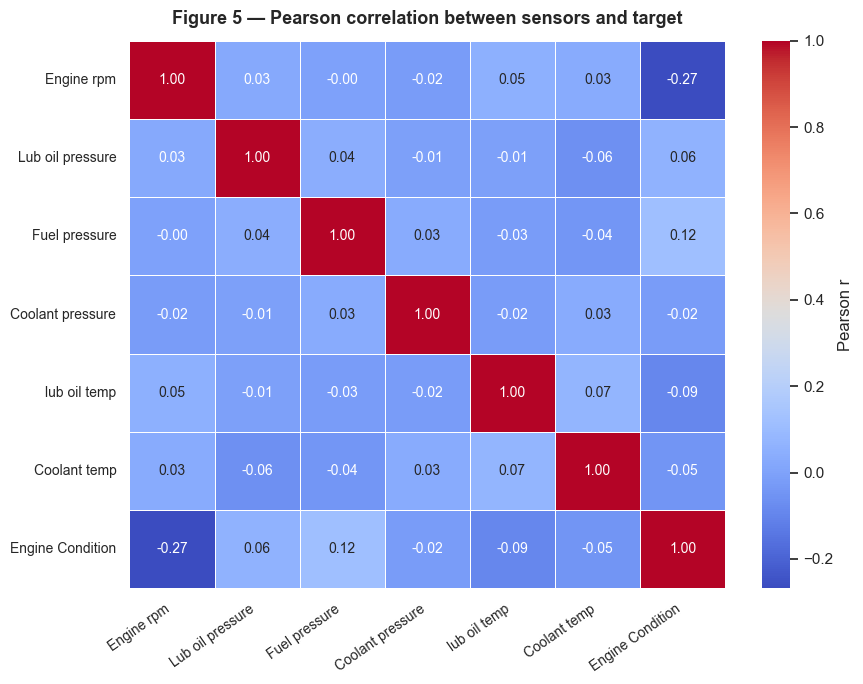

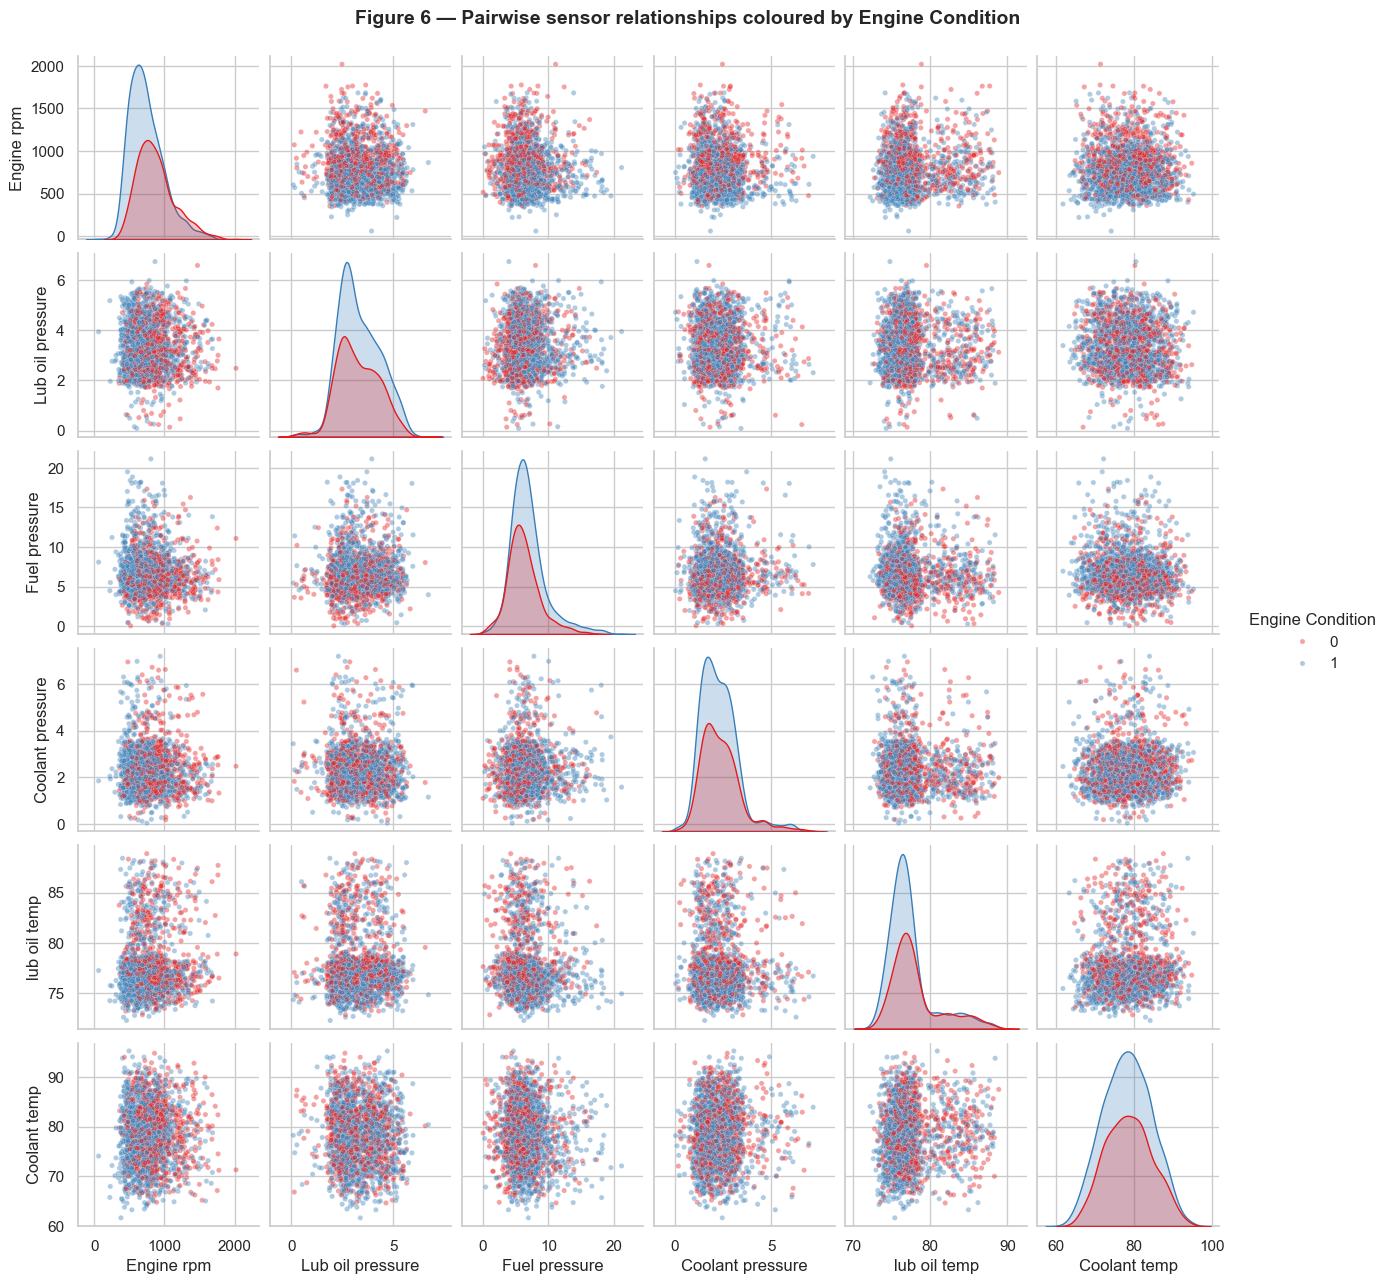

In [11]:
# Figure 5 — Pearson correlation matrix
plt.figure(figsize=(9, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, annot_kws={"size": 10},
            cbar_kws={"label": "Pearson r"})
plt.title("Figure 5 — Pearson correlation between sensors and target",
          fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=35, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Figure 6 — Pairplot on a 2,000-row stratified-style random sample
sample = df.sample(n=2000, random_state=42)
g = sns.pairplot(sample, vars=numeric_features, hue=target, diag_kind="kde",
                 plot_kws={"alpha": 0.4, "s": 14}, palette="Set1", height=2.1)
g.fig.suptitle("Figure 6 — Pairwise sensor relationships coloured by Engine Condition",
               fontsize=14, fontweight="bold", y=1.02)
plt.show()


### 4.7 Insights / Observations from EDA

1. **Dataset size & quality** — 19,535 rows × 7 columns; no missing values and no duplicates. All features are numeric, so no encoding is required.
2. **Target imbalance** — Faulty engines (`1`) make up ~63 % of records and healthy engines (`0`) ~37 %. Moderate imbalance — we will use class weights in the model rather than resampling.
3. **Engine RPM** is the strongest single predictor (Pearson correlation with target ≈ **−0.27**, see Figure 5). Faulty engines run at a noticeably *lower* mean RPM (~736) than healthy engines (~885) — consistent with engines that are losing power.
4. **Fuel pressure** has a positive correlation (~+0.12); faulty engines show slightly *higher* fuel pressure on average, possibly indicating clogged injectors / poor combustion.
5. **Lub-oil temperature** shows mild negative correlation (~−0.09); the rest of the sensors are weakly correlated with the target individually — this confirms that no single sensor is sufficient and a **non-linear model** (tree-based ensemble) is warranted.
6. **Outliers** — `Coolant temp` has a couple of extreme values (one ≈ 195 °C — physically implausible for sustained operation, visible in Figure 2); the right tails of `Fuel pressure` and `Coolant pressure` also contain a long tail. We will clip extreme `Coolant temp` outliers in data preparation but keep the rest, since trees are robust to mild outliers.
7. **Inter-feature correlation** is very low (|r| < 0.1 across predictors, Figure 5) → no multicollinearity concerns; all six sensors can be retained.
8. **Modelling plan** — Use tree-based ensemble methods (Decision Tree, Random Forest, Gradient Boosting, XGBoost). They handle the mixed scale, mild skew, and outliers natively, and they can capture non-linear interactions invisible to the univariate plots.


---
## 3. Data Registration on Hugging Face


In [9]:
from huggingface_hub import create_repo
from huggingface_hub.utils import RepositoryNotFoundError

# Step 1: copy the raw csv into ./data
src_csv = PROJECT_ROOT / "engine_data.csv"
dst_csv = DATA_DIR / "engine_data.csv"
shutil.copyfile(src_csv, dst_csv)
print(f"Copied {src_csv.name} -> {dst_csv.relative_to(PROJECT_ROOT)}")

df = pd.read_csv(dst_csv)

# --- Data cleaning ---
clean = df.copy()

# Standardise column names (remove spaces, lower-case, snake_case)
clean.columns = (
    clean.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.lower()
)
print("Renamed columns:", list(clean.columns))

# Drop duplicates (none expected) and rows with NA (none expected) - defensive
before = len(clean)
clean = clean.drop_duplicates().dropna()
print(f"Removed {before - len(clean)} duplicate/NA rows.")

# Clip the obvious sensor artefact on coolant_temp (max ~195 °C is non-physical)
upper_coolant = clean["coolant_temp"].quantile(0.999)
n_clipped = (clean["coolant_temp"] > upper_coolant).sum()
clean["coolant_temp"] = clean["coolant_temp"].clip(upper=upper_coolant)
print(f"Clipped {n_clipped} extreme coolant_temp values above {upper_coolant:.2f} °C.")

# All six sensor columns are predictive — no columns to drop
print("Final shape:", clean.shape)

clean.to_csv(DATA_DIR / "engine_data.csv", index=False)

# Step 2: ensure the HF dataset repo exists
try:
    api.repo_info(repo_id=DATASET_REPO_ID, repo_type="dataset")
    print(f"Dataset repo '{DATASET_REPO_ID}' already exists. Using it.")
except RepositoryNotFoundError:
    create_repo(repo_id=DATASET_REPO_ID, repo_type="dataset", private=False, token=HF_TOKEN)
    print(f"Dataset repo '{DATASET_REPO_ID}' created.")

# Step 3: upload the data folder
api.upload_folder(
    folder_path=str(DATA_DIR),
    repo_id=DATASET_REPO_ID,
    repo_type="dataset",
    commit_message="Register raw engine_data.csv",
)
print(f"Raw dataset registered at: https://huggingface.co/datasets/{DATASET_REPO_ID}")

Copied engine_data.csv -> predictive_maintenance\data\engine_data.csv
Renamed columns: ['engine_rpm', 'lub_oil_pressure', 'fuel_pressure', 'coolant_pressure', 'lub_oil_temp', 'coolant_temp', 'engine_condition']
Removed 0 duplicate/NA rows.
Clipped 20 extreme coolant_temp values above 94.06 °C.
Final shape: (19535, 7)
Dataset repo 'debasishdas1985/engine-predictive-maintenance' already exists. Using it.


No files have been modified since last commit. Skipping to prevent empty commit.


Raw dataset registered at: https://huggingface.co/datasets/debasishdas1985/engine-predictive-maintenance


In [10]:
import pandas as pd
df = pd.read_csv(DATA_DIR / "engine_data.csv")
df.head()

,engine_rpm,lub_oil_pressure,fuel_pressure,coolant_pressure,lub_oil_temp,coolant_temp,engine_condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


---
## Data Preparation

In [37]:
%%writefile predictive_maintenance/model_building/data_register.py
from huggingface_hub.utils import RepositoryNotFoundError, HfHubHTTPError
from huggingface_hub import HfApi, create_repo
import os

# Initialize API client
api = HfApi(token=os.getenv("HF_TOKEN"))
user_info = api.whoami()
HF_USER = user_info["name"]
print("Authenticated as:", HF_USER)


DATA_DIR = "predictive_maintenance/data"

# Repo identifiers used throughout the notebook
DATASET_REPO_ID = f"{HF_USER}/engine-predictive-maintenance"

# Step 1: Check if the space exists
try:
    api.repo_info(repo_id=DATASET_REPO_ID, repo_type="dataset")
    print(f"Space '{DATASET_REPO_ID}' already exists. Using it.")
except RepositoryNotFoundError:
    print(f"Space '{DATASET_REPO_ID}' not found. Creating new space...")
    create_repo(repo_id=DATASET_REPO_ID, repo_type="dataset", private=False)
    print(f"Space '{DATASET_REPO_ID}' created.")

api.upload_folder(
    folder_path=DATA_DIR,
    repo_id=DATASET_REPO_ID,
    repo_type="dataset",
)

Overwriting predictive_maintenance/model_building/data_register.py


In [2]:
%%writefile predictive_maintenance/model_building/prep.py
# for data manipulation
import pandas as pd
import sklearn
# for creating a folder
import os
# for data preprocessing and pipeline creation
from sklearn.model_selection import train_test_split
# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# Initialize API client
api = HfApi(token=os.getenv("HF_TOKEN"))
user_info = api.whoami()
HF_USER = user_info["name"]
print("Authenticated as:", HF_USER)


DATA_DIR = "predictive_maintenance/data"

# Repo identifiers used throughout the notebook
DATASET_REPO_ID = f"{HF_USER}/engine-predictive-maintenance"

DATASET_PATH = f"hf://datasets/{DATASET_REPO_ID}/engine_data.csv"
engine_dataset = pd.read_csv(DATASET_PATH)
print("Dataset loaded successfully.")

# Define the target variable for the classification task
target = 'engine_condition'

# List of features in the dataset (all engine sensor readings)
features = [
    'engine_rpm', 'lub_oil_pressure', 'fuel_pressure',
    'coolant_pressure', 'lub_oil_temp', 'coolant_temp'
]

# Define predictor matrix (X) using selected numeric and categorical features
X = engine_dataset[features]

# Define target variable
y = engine_dataset[target]


# Split dataset into train and test
# Split the dataset into training and test sets
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y,              # Predictors (X) and target variable (y)
    test_size=0.2,     # 20% of the data is reserved for testing
    random_state=42    # Ensures reproducibility by setting a fixed random seed
)

Xtrain.to_csv(os.path.join(DATA_DIR, "Xtrain.csv"), index=False)
Xtest.to_csv(os.path.join(DATA_DIR, "Xtest.csv"), index=False)
ytrain.to_csv(os.path.join(DATA_DIR, "ytrain.csv"), index=False)
ytest.to_csv(os.path.join(DATA_DIR, "ytest.csv"), index=False)


files = ["Xtrain.csv","Xtest.csv","ytrain.csv","ytest.csv"]

for file_path in files:
    api.upload_file(
        path_or_fileobj=os.path.join(DATA_DIR, file_path),
        path_in_repo=file_path,  # just the filename
        repo_id=DATASET_REPO_ID,
        repo_type="dataset",
    )

Overwriting predictive_maintenance/model_building/prep.py


---
## Model Training and Registration with Experimentation Tracking

NGROK_API_KEY: Set
Starting MLflow UI server...
Creating ngrok tunnel...


t=2026-05-31T14:49:58+0530 lvl=warn msg="failed to check for update" obj=updater err="Server responded with 403 Forbidden: <!--# WtK5kRMsfkqQqL0rSZDrNT0F6SJSnqWR0j7JjsFd-->\n<!DOCTYPE HTML PUBLIC \"-//W3C//DTD HTML 4.01 Transitional//EN\" \"http://www.w3c.org/TR/1999/REC-html401-19991224/loose.dtd\">\n<html>\n<head>\n<meta name=\"description\" content=\"Zscaler makes the internet safe for businesses by protecting their employees from malware, viruses, and other security threats.\">\n<meta http-equiv=\"Content-Type\" content=\"text/html; charset=utf-8\">\n<meta name=\"viewport\" content=\"width=device-width, initial-scale=1\">\n<title>Internet Security by Zscaler</title>\n<script language=\"JavaScript\">var defLang = 'en_US'</script>\n<!--Wolters Kluwer-->\n<style type=\"text/css\">\nbody {\nbackground-color:#e3e3e3;\nfont-family:Arial, sans-serif;\nfont-size:12px;\ncolor:#4B4F54;\n}\na {\ncursor:pointer;\ntext-decoration:none;\ncolor:#009dd0;\n}\ntable {\nmargin-top:10px;\n}\ntd table 
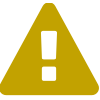

✓ MLflow UI is available at: https://unsandalled-kailey-uncontortedly.ngrok-free.dev


In [18]:
import time
from pyngrok import ngrok
import subprocess
import mlflow
from dotenv import load_dotenv
load_dotenv()
auth_token = os.getenv("NGROK_API_KEY")
print("NGROK_API_KEY:", "Set" if auth_token else "Not set")
# Set your auth token here (replace with your actual token)
ngrok.set_auth_token(auth_token)

# Start MLflow UI on port 5000
print("Starting MLflow UI server...")
process = subprocess.Popen(
    ["mlflow", "ui", "--port", "5000"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

# Wait for MLflow server to fully start
time.sleep(3)

# Create public tunnel for UI viewing ONLY
print("Creating ngrok tunnel...")
public_url = ngrok.connect(5000).public_url
print(f"✓ MLflow UI is available at: {public_url}")

# Wait for tunnel to stabilize
time.sleep(2)

In [19]:
# Set the tracking URL to localhost (NOT ngrok, since MLflow is running locally)
mlflow.set_tracking_uri("http://localhost:5000")
print("✓ MLflow tracking URI set to: http://localhost:5000")

# Set the name for the experiment
mlflow.set_experiment("engine-predictive-maintenance-experiment")
print("✓ MLflow experiment ready for logging")

✓ MLflow tracking URI set to: http://localhost:5000
✓ MLflow experiment ready for logging


In [ ]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, recall_score
import xgboost as xgb
import joblib
import mlflow

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("predictive-maintenance-experiment")

DATA_DIR = "data"
Xtrain = pd.read_csv(f"{DATA_DIR}/Xtrain.csv")
Xtest  = pd.read_csv(f"{DATA_DIR}/Xtest.csv")
ytrain = pd.read_csv(f"{DATA_DIR}/ytrain.csv").squeeze("columns")
ytest  = pd.read_csv(f"{DATA_DIR}/ytest.csv").squeeze("columns")
print(f"Train set size: {Xtrain.shape[0]} | Test set size: {Xtest.shape[0]}")
print(f"Target distribution (train):\n{ytrain.value_counts()}")


# All predictors are numeric engine-sensor readings — no categorical features
# (column names match the snake_case headers stored in data/Xtrain.csv)
numeric_features = [
    'engine_rpm', 'lub_oil_pressure', 'fuel_pressure',
    'coolant_pressure', 'lub_oil_temp', 'coolant_temp'
]

# Class-weight to handle the (mild) imbalance between healthy / faulty engines
class_weight = ytrain.value_counts()[0] / ytrain.value_counts()[1]
print(f"Class weight (scale_pos_weight): {class_weight:.2f}")

# Preprocessing: scale all numeric sensor features
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features)
)

# Base XGBoost classifier
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=class_weight, random_state=42, verbosity=0,
    eval_metric="logloss"
)

# Hyperparameter grid
param_grid = {
    'xgbclassifier__n_estimators':      [50, 75, 100],
    'xgbclassifier__max_depth':         [2, 3, 4],
    'xgbclassifier__colsample_bytree':  [0.4, 0.6],
    'xgbclassifier__colsample_bylevel': [0.4, 0.6],
    'xgbclassifier__learning_rate':     [0.01, 0.1],
    'xgbclassifier__reg_lambda':        [0.4, 0.6],
}

# Full model pipeline (preprocessor + classifier)
model_pipeline = make_pipeline(preprocessor, xgb_model)

print("Starting model training with GridSearchCV...")

with mlflow.start_run():
    # Hyperparameter tuning
    grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(Xtrain, ytrain)

    # Log every parameter combination as a nested run
    results = grid_search.cv_results_
    for i in range(len(results['params'])):
        with mlflow.start_run(nested=True):
            mlflow.log_params(results['params'][i])
            mlflow.log_metric("mean_test_score", results['mean_test_score'][i])
            mlflow.log_metric("std_test_score", results['std_test_score'][i])

    # Log the best run in the parent
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("best_cv_score", grid_search.best_score_)

    # Evaluate the best model with a custom classification threshold
    best_model = grid_search.best_estimator_
    print(f"Best CV Score : {grid_search.best_score_:.4f}")
    print(f"Best Params   : {grid_search.best_params_}")

    classification_threshold = 0.45

    y_pred_train_proba = best_model.predict_proba(Xtrain)[:, 1]
    y_pred_train = (y_pred_train_proba >= classification_threshold).astype(int)

    y_pred_test_proba = best_model.predict_proba(Xtest)[:, 1]
    y_pred_test = (y_pred_test_proba >= classification_threshold).astype(int)

    train_report = classification_report(ytrain, y_pred_train, output_dict=True)
    test_report  = classification_report(ytest,  y_pred_test,  output_dict=True)

    mlflow.log_metrics({
        "train_accuracy":  train_report['accuracy'],
        "train_precision": train_report['1']['precision'],
        "train_recall":    train_report['1']['recall'],
        "train_f1-score":  train_report['1']['f1-score'],
        "test_accuracy":   test_report['accuracy'],
        "test_precision":  test_report['1']['precision'],
        "test_recall":     test_report['1']['recall'],
        "test_f1-score":   test_report['1']['f1-score'],
    })

    # Persist the best estimator locally for the Hugging Face model-hub upload step
    model_path = "best_engine_model.joblib"
    joblib.dump(best_model, model_path)
    mlflow.log_artifact(model_path)

    print("\nModel Performance Metrics")
    print(f"Train Accuracy : {train_report['accuracy']:.4f}")
    print(f"Test  Accuracy : {test_report['accuracy']:.4f}")
    print(f"Test  Precision: {test_report['1']['precision']:.4f}")
    print(f"Test  Recall   : {test_report['1']['recall']:.4f}")
    print(f"Test  F1-Score : {test_report['1']['f1-score']:.4f}")

print("Model training and MLflow logging completed!")

Train set size: 15628 | Test set size: 3907
Target distribution (train):
engine_condition
1    9854
0    5774
Name: count, dtype: int64
Preprocessed data loaded successfully from Hugging Face.
Class weight (scale_pos_weight): 0.59
Starting model training with GridSearchCV...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
🏃 View run casual-worm-817 at: http://localhost:5000/#/experiments/959659641840159731/runs/026edf1413644f1e8ed15abf41277550
🧪 View experiment at: http://localhost:5000/#/experiments/959659641840159731
🏃 View run adaptable-finch-683 at: http://localhost:5000/#/experiments/959659641840159731/runs/3fea867e3f004ad7b31924f7f651341e
🧪 View experiment at: http://localhost:5000/#/experiments/959659641840159731
🏃 View run learned-bird-520 at: http://localhost:5000/#/experiments/959659641840159731/runs/9dcbdc6b1e714756bbccfc8fcb4733ef
🧪 View experiment at: http://localhost:5000/#/experiments/959659641840159731
🏃 View run overjoyed-croc-867 at: http://localhost:50

In [4]:
%%writefile predictive_maintenance/model_building/train.py
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, recall_score
import xgboost as xgb
import joblib
import mlflow
from huggingface_hub import login, HfApi
import os

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("predictive-maintenance-experiment")

api = HfApi(token=os.getenv("HF_TOKEN"))
user_info = api.whoami()
HF_USER = user_info["name"]
print("Authenticated as:", HF_USER)

# Repo identifiers used throughout the notebook
DATASET_REPO_ID = f"{HF_USER}/engine-predictive-maintenance"
MODEL_REPO_ID = f"{HF_USER}/engine-predictive-maintenance-model"

# Load preprocessed data from Hugging Face
Xtrain_path = f"hf://datasets/{DATASET_REPO_ID}/Xtrain.csv"
Xtest_path = f"hf://datasets/{DATASET_REPO_ID}/Xtest.csv"
ytrain_path = f"hf://datasets/{DATASET_REPO_ID}/ytrain.csv"
ytest_path = f"hf://datasets/{DATASET_REPO_ID}/ytest.csv"

Xtrain = pd.read_csv(Xtrain_path)
Xtest = pd.read_csv(Xtest_path)
ytrain = pd.read_csv(ytrain_path).squeeze()
ytest = pd.read_csv(ytest_path).squeeze()

print("Preprocessed data loaded successfully from Hugging Face.")

# All predictors are numeric engine-sensor readings — no categorical features
# (column names match the snake_case headers stored in data/Xtrain.csv)
numeric_features = [
    'engine_rpm', 'lub_oil_pressure', 'fuel_pressure',
    'coolant_pressure', 'lub_oil_temp', 'coolant_temp'
]

# Class-weight to handle the (mild) imbalance between healthy / faulty engines
class_weight = ytrain.value_counts()[0] / ytrain.value_counts()[1]
print(f"Class weight (scale_pos_weight): {class_weight:.2f}")

# Preprocessing: scale all numeric sensor features
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features)
)

# Base XGBoost classifier
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=class_weight, random_state=42, verbosity=0,
    eval_metric="logloss"
)

# Hyperparameter grid
param_grid = {
    'xgbclassifier__n_estimators':      [50, 75, 100],
    'xgbclassifier__max_depth':         [2, 3, 4],
    'xgbclassifier__colsample_bytree':  [0.4, 0.6],
    'xgbclassifier__colsample_bylevel': [0.4, 0.6],
    'xgbclassifier__learning_rate':     [0.01, 0.1],
    'xgbclassifier__reg_lambda':        [0.4, 0.6],
}

# Full model pipeline (preprocessor + classifier)
model_pipeline = make_pipeline(preprocessor, xgb_model)

print("Starting model training with GridSearchCV...")

with mlflow.start_run():
    # Hyperparameter tuning
    grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)
    grid_search.fit(Xtrain, ytrain)

    # Log every parameter combination as a nested run
    results = grid_search.cv_results_
    for i in range(len(results['params'])):
        with mlflow.start_run(nested=True):
            mlflow.log_params(results['params'][i])
            mlflow.log_metric("mean_test_score", results['mean_test_score'][i])
            mlflow.log_metric("std_test_score", results['std_test_score'][i])

    # Log the best run in the parent
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("best_cv_score", grid_search.best_score_)

    # Evaluate the best model with a custom classification threshold
    best_model = grid_search.best_estimator_
    print(f"Best CV Score : {grid_search.best_score_:.4f}")
    print(f"Best Params   : {grid_search.best_params_}")

    classification_threshold = 0.45

    y_pred_train_proba = best_model.predict_proba(Xtrain)[:, 1]
    y_pred_train = (y_pred_train_proba >= classification_threshold).astype(int)

    y_pred_test_proba = best_model.predict_proba(Xtest)[:, 1]
    y_pred_test = (y_pred_test_proba >= classification_threshold).astype(int)

    train_report = classification_report(ytrain, y_pred_train, output_dict=True)
    test_report  = classification_report(ytest,  y_pred_test,  output_dict=True)

    mlflow.log_metrics({
        "train_accuracy":  train_report['accuracy'],
        "train_precision": train_report['1']['precision'],
        "train_recall":    train_report['1']['recall'],
        "train_f1-score":  train_report['1']['f1-score'],
        "test_accuracy":   test_report['accuracy'],
        "test_precision":  test_report['1']['precision'],
        "test_recall":     test_report['1']['recall'],
        "test_f1-score":   test_report['1']['f1-score'],
    })

    # Save the model locally
    model_path = "engine-predictive-maintenance-model.joblib"
    joblib.dump(best_model, model_path)

    # Log the model artifact
    mlflow.log_artifact(model_path, artifact_path="model")
    print(f"Model saved as artifact at: {model_path}")

    # Upload to Hugging Face
    repo_id = MODEL_REPO_ID
    repo_type = "model"

    # Step 1: Check if the model repo exists
    try:
        api.repo_info(repo_id=repo_id, repo_type=repo_type)
        print(f"Model repository '{repo_id}' already exists. Using it.")
    except RepositoryNotFoundError:
        print(f"Model repository '{repo_id}' not found. Creating new repository...")
        create_repo(repo_id=repo_id, repo_type=repo_type, private=False)
        print(f"Model repository '{repo_id}' created.")

    # Upload the model file to Hugging Face
    api.upload_file(
        path_or_fileobj=model_path,
        path_in_repo=model_path,
        repo_id=repo_id,
        repo_type=repo_type,
    )
    
    print("Model successfully uploaded to Hugging Face!")

print("Model training and registration completed!")

Overwriting predictive_maintenance/model_building/train.py


In [27]:
os.makedirs("predictive_maintenance/deployment", exist_ok=True)

In [6]:
%%writefile predictive_maintenance/deployment/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

RUN useradd -m -u 1000 user
USER user
ENV HOME=/home/user \
	PATH=/home/user/.local/bin:$PATH

WORKDIR $HOME/app

COPY --chown=user . $HOME/app

# Define the command to run the Streamlit app on port "8501" and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Writing predictive_maintenance/deployment/Dockerfile


---
## Streamlit App

In [31]:
%%writefile predictive_maintenance/deployment/app.py

import streamlit as st
import pandas as pd
from huggingface_hub import hf_hub_download
import joblib

# Download the model from the Hugging Face Model Hub
model_path = hf_hub_download(
    repo_id="debasishdas1985/engine-predictive-maintenance-model",
    filename="engine-predictive-maintenance-model.joblib",
)

# Load the model
model = joblib.load(model_path)

# Streamlit UI for Engine Predictive Maintenance
st.title("Engine Predictive Maintenance App")
st.write(
    "This app predicts whether an engine is likely to require maintenance "
    "based on six real-time sensor readings. It is intended as an internal "
    "decision-support tool for reliability and maintenance engineers."
)
st.write("Kindly enter the latest engine sensor readings below to assess its condition.")

# Layout — two columns for sensor groups
col1, col2 = st.columns(2)

with col1:
    st.subheader("Engine & Lubrication")
    engine_rpm = st.number_input(
        "Engine RPM (revolutions per minute)",
        min_value=0, max_value=3000, value=700,
    )
    lub_oil_pressure = st.number_input(
        "Lubricating Oil Pressure (bar)",
        min_value=0.0, max_value=10.0, value=2.5, step=0.1,
    )
    lub_oil_temp = st.number_input(
        "Lubricating Oil Temperature (°C)",
        min_value=0.0, max_value=150.0, value=84.1, step=0.1,
    )

with col2:
    st.subheader("Fuel & Coolant")
    fuel_pressure = st.number_input(
        "Fuel Pressure (bar)",
        min_value=0.0, max_value=30.0, value=11.8, step=0.1,
    )
    coolant_pressure = st.number_input(
        "Coolant Pressure (bar)",
        min_value=0.0, max_value=10.0, value=3.2, step=0.1,
    )
    coolant_temp = st.number_input(
        "Coolant Temperature (°C)",
        min_value=0.0, max_value=150.0, value=81.6, step=0.1,
    )

# Build the input frame in the exact feature order used during training
input_data = pd.DataFrame([{
    "engine_rpm": engine_rpm,
    "lub_oil_pressure": lub_oil_pressure,
    "fuel_pressure": fuel_pressure,
    "coolant_pressure": coolant_pressure,
    "lub_oil_temp": lub_oil_temp,
    "coolant_temp": coolant_temp,
}])

# Classification threshold (tuned for recall on the maintenance-required class)
classification_threshold = 0.50

# Predict button
if st.button("Predict Engine Condition", use_container_width=True):
    try:
        prediction_proba = model.predict_proba(input_data)[0, 1]
        prediction = int(prediction_proba >= classification_threshold)

        st.divider()
        if prediction == 1:
            st.error("Expected Outcome: Engine is LIKELY to REQUIRE MAINTENANCE")
            st.metric("Maintenance Risk", f"{prediction_proba*100:.2f}%")
        else:
            st.success("Expected Outcome: Engine appears to be in HEALTHY condition")
            st.metric("Maintenance Risk", f"{prediction_proba*100:.2f}%")
        st.divider()

        with st.expander("View input sent to the model"):
            st.dataframe(input_data, use_container_width=True)
    except Exception as e:
        st.error(f"Error making prediction: {str(e)}")
        st.info("Please ensure all sensor readings are filled correctly.")

# Footer
st.markdown("---")
st.caption(
    "Powered by Engine Predictive Maintenance MLOps Pipeline | "
    "XGBoost Model v1.0 | Confidence Threshold: 50%"
)


Overwriting predictive_maintenance/deployment/app.py


In [32]:
%%writefile predictive_maintenance/deployment/requirements.txt
pandas==2.2.2
huggingface_hub==0.32.6
streamlit==1.43.2
joblib==1.5.1
scikit-learn==1.6.0
xgboost==2.1.4
mlflow==3.0.1

Overwriting predictive_maintenance/deployment/requirements.txt


In [34]:
os.makedirs("predictive_maintenance/hosting", exist_ok=True)

In [ ]:
%%writefile predictive_maintenance/hosting/hosting.py
from huggingface_hub import HfApi
import os

api = HfApi(token=os.getenv("HF_TOKEN"))
user_info = api.whoami()
HF_USER = user_info["name"]
print("Authenticated as:", HF_USER)

# Repo identifiers used throughout the notebook
APP_REPO_ID = f"{HF_USER}/engine-predictive-maintenance"
 # Step 1: Check if the model repo exists
try:
    api.repo_info(repo_id=APP_REPO_ID, repo_type="space")
    print(f"Model repository '{APP_REPO_ID}' already exists. Using it.")
except RepositoryNotFoundError:
    print(f"Model repository '{APP_REPO_ID}' not found. Creating new repository...")
    create_repo(repo_id=APP_REPO_ID, repo_type="space", private=False)
    print(f"Model repository '{APP_REPO_ID}' created.")

api.upload_folder(
    folder_path="predictive_maintenance/deployment",     # the local folder containing your files
    repo_id=APP_REPO_ID,          # the target repo
    repo_type="space",                      # dataset, model, or space
    path_in_repo="",                          # optional: subfolder path inside the repo
)

Overwriting predictive_maintenance/hosting/hosting.py
